# Tabula Muris Imbalance

We attempt to reproduce a study conducted in paper: https://link.springer.com/article/10.1186/s13059-022-02622-0#Sec12

__From Results__: Figure 5a shows the performance on the number of cell type estimation in each imbalanced setting for each of the 14 clustering algorithms, and Fig. 5b quantifies the concordance of cell clustering to cell type labels averaged across the results from 10 and 20 cell types. We found that the imbalanced ratio of cells in major and minor cell types in general leads to a reduction in the estimated number of cell types when the ratio increases (Fig. 5a). This unintended reduction helps methods that tend to over-estimate the number of cell types (e.g. Seurat, SC3, ACTIONet) but results in under-estimation for others (e.g. scLCA, scCCESS-Kmeans, scCCESS-SIMLR). Again, the performance on cell clustering does not always match the accuracy of the number of cell type estimation (e.g. Seurat) (Fig. 5b and Additional File 1: Fig S5). These results suggest that the imbalance ratio of cells in major and minor cell types has an uneven impact on different clustering algorithms and the number of cell types (e.g. 10 and 20) in a dataset tends to be the key driver on their performance of the number of cell type estimation.

(_Note that scLCA uses the silhouette statistic._)

__From Methods__: To create datasets with varying but well-defined characteristics, we took advantage of the large number of cells and cell types profiled by the Tabula Muris project [34] by subsampling from this dataset different numbers of cells and types and creating different imbalance ratios (described below). Specifically, Tabula Muris dataset contains 53,760 cells (FACS sorted and sequenced using Smart-Seq2 protocol) from 81 cell types of 20 organs of 7 mice. Cell types that include no more than 300 cells were excluded from this study. Overall, 38 cell types with 39,712 cells and 23,433 genes were included in the selection pool after filtering.

[...]

In the third setting, we tested the impact of datasets with different imbalance ratios by creating major and minor cell types that contain different numbers of cells. First, we sampled from Tabula Muris dataset 10 or 20 cell types and divided them into two equal groups for creating major and minor cell types (i.e. 5 or 10 cell types each for 10 and 20, respectively). We then created major and minor cell types by setting the number of cells in the major cell types as 200 and varying the number of cells in the minor cell types as 100, 50, and 20, leading to imbalance ratios of 2:1, 4:1, and 10:1 for the major and minor cell types. Again, we repeated the sampling 10 times, resulting in 60 datasets (i.e. 2 × 3 × 10).

## 0. Imports & Set-Up:

In [175]:
import os
import random
import inspect
import multiprocessing
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.optimize import linear_sum_assignment

from joblib import Parallel, delayed

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances, 
    confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import check_random_state

import matplotlib.pyplot as plt

import scanpy as sc

from carve import CARVE
from carve.config import ValidatorConfig

In [133]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [134]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [135]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [176]:
def gamma_quantiles_approx(
    X: np.ndarray,
    qs: Tuple[float, ...] = (0.05, 0.10, 0.25, 0.50),
    max_points: int = 500,
    random_state: int = 0,
) -> List[float]:
    rng = check_random_state(random_state)
    n = X.shape[0]
    Xs = X[rng.choice(n, size=max_points, replace=False)] if n > max_points else X

    D2 = pairwise_distances(Xs, metric="sqeuclidean")
    d2 = D2[np.triu_indices_from(D2, k=1)]
    d2 = d2[np.isfinite(d2)]
    if d2.size == 0:
        return [1.0 for _ in qs]
    return [float(1.0 / (2.0 * np.quantile(d2, q))) for q in qs]

The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [136]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

`align_labels` aligns arbitrary cluster labels to a set of reference labels by maximizing agreement via the Hungarian algorithm. This is useful because clustering algorithms assign label IDs arbitrarily, and direct comparison to true labels requires a permutation alignment.

**Inputs**
- `true_labels` (`np.ndarray`): Ground-truth labels for each sample (preferably integer-coded, e.g., `pd.Categorical(...).codes`).
- `pred_labels` (`np.ndarray`): Predicted cluster labels for each sample (arbitrary IDs).

**Process**
1. Computes the confusion matrix `cm` between `true_labels` and `pred_labels`.
2. Applies the Hungarian algorithm (`linear_sum_assignment`) to `-cm` to find the permutation of predicted labels that maximizes total matches.
3. Builds a mapping from predicted labels to matched true labels.
4. Re-labels `pred_labels` according to this mapping; any predicted label not present in the mapping is left unchanged.

**Output**
- `np.ndarray`: Aligned predicted labels with IDs permuted to best match `true_labels` (same shape as `pred_labels`).

In [137]:
def align_labels(true_labels, pred_labels):
    """
    Aligns predicted cluster labels to true labels by maximizing agreement using the Hungarian algorithm.

    Args:
        true_labels (np.ndarray): Ground-truth labels for each sample (integer-coded).
        pred_labels (np.ndarray): Predicted cluster labels for each sample (arbitrary IDs).

    Returns:
        np.ndarray: Aligned predicted labels with IDs permuted to best match true_labels.
    """
    cm = confusion_matrix(true_labels, pred_labels)
    
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    label_map = {old: new for old, new in zip(col_ind, row_ind)}
    return np.array([label_map[l] if l in label_map else l for l in pred_labels])

The following functions implement the **Gap Statistic** method for determining the optimal number of clusters in a dataset.  
They work together to quantify how much better the observed clustering is compared to what would be expected under a reference (null) distribution with no inherent structure.

##### Function 1: `compute_dispersion`
Computes the within-cluster dispersion measure \( W_k \), which quantifies how tightly points are grouped within each cluster.

**Inputs**
- `X` (`np.ndarray`): Data matrix with samples as rows and features as columns.  
- `labels` (`np.ndarray`): Cluster labels for each observation.  
- `metric` (`str`, default `'euclidean'`): Distance metric used to compute pairwise distances within clusters.

**Process**
1. Iterates over all unique cluster labels.  
2. For each cluster, computes all pairwise distances between points.  
3. Averages the total within-cluster distances, normalized by the number of points.  
4. Sums these values across clusters to obtain total within-cluster dispersion.

**Output**
- Returns a single float `W_k`: the total within-cluster dispersion.

##### Function 2: `gen_null`
Generates a reference dataset (null model) by independently sampling each feature from a uniform distribution spanning the observed feature range.

**Inputs**
- `X` (`np.ndarray`): Original dataset.  
- `_` (`int`): Placeholder (unused).  
- `random_state` (`int`): Seed for reproducibility.

**Process**
1. For each feature (column), samples uniformly between its observed minimum and maximum.  
2. Produces a dataset with the same shape as `X` but without clustering structure.

**Output**
- Returns `X_ref` (`np.ndarray`): Null (reference) dataset.

##### Function 3: `gap_statistic`
Computes the Gap Statistic comparing observed clustering dispersion to that expected under the null model.

**Inputs**
- `X` (`np.ndarray`): Data matrix.  
- `labels` (`np.ndarray`): Cluster labels from a fitted clustering algorithm.  
- `metric` (`str`, default `'euclidean'`): Distance metric for dispersion calculation.  
- `n_refs` (`int`, default `10`): Number of reference datasets to generate.  
- `algorithm` (`Type[ClusterMixin]`, default `KMeans`): Clustering algorithm used for reference clustering.  
- `random_state` (`int` or `None`): Random seed for reproducibility.

**Process**
1. Computes observed within-cluster dispersion `W_k`.  
2. Generates `n_refs` null datasets via `gen_null`.  
3. Clusters each null dataset and computes its log-dispersion.  
4. Estimates the expected log-dispersion under the null model.  
5. Computes the Gap Statistic:  
   $$
   \text{Gap}(k) = E[\log(W_k^{\text{null}})] - \log(W_k)
   $$
   Larger gaps indicate more distinct clustering structure than expected by chance.

**Output**
- Returns a single float `gap`: the computed Gap Statistic value for the given clustering configuration.


In [138]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Computes the within-cluster dispersion measure W_k for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').

    Returns:
        float: Total within-cluster dispersion W_k.
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric, squared=True)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null_box(X: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Uniform reference distribution over the axis-aligned bounding box of X."""
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    span = maxs - mins
    return rng.random(size=X.shape) * span + mins

def _pick_first(v):
    return v[0] if isinstance(v, (list, tuple)) else v

def _build_estimator(
    algorithm: Type[ClusterMixin],
    k: int,
    algorithm_params: dict | None,
    seed: int,
):
    # start with the fixed params coming from model_grids[0][1]
    params = {}
    if algorithm_params:
        for key, val in algorithm_params.items():
            if key == "n_clusters":
                continue
            
            params[key] = _pick_first(val)

    # set k for this call
    params["n_clusters"] = k

    # set random_state when supported
    sig = inspect.signature(algorithm.__init__)
    if "random_state" in sig.parameters:
        params["random_state"] = seed

    # pin kmeans defaults across sklearn versions
    if algorithm.__name__ == "KMeans" or algorithm is KMeans:
        if "n_init" in sig.parameters and "n_init" not in params:
            params["n_init"] = 10

    return algorithm(**params)

def gap_statistic(
    X: np.ndarray,
    labels: np.ndarray,
    metric: str = "euclidean",
    n_refs: int = 10,
    algorithm: Type[ClusterMixin] = KMeans,
    algorithm_params: dict | None = None,
    random_state: int = 0,
) -> float:
    """
    Gap(k) = E[log W*_k] - log W_k, with W_k computed from provided labels.
    """
    rng = np.random.default_rng(int(random_state))

    W_k = compute_dispersion(X, labels, metric)
    if not np.isfinite(W_k) or W_k <= 0:
        return np.nan

    k = int(np.unique(labels).size)

    ref_log_disps = np.empty(n_refs, dtype=float)
    for b in range(n_refs):
        X_ref = gen_null_box(X, rng)
        seed_b = int(rng.integers(0, 2**32 - 1))

        est = _build_estimator(algorithm, k, algorithm_params, seed_b)
        ref_labels = est.fit_predict(X_ref)

        W_ref = compute_dispersion(X_ref, ref_labels, metric)
        ref_log_disps[b] = np.log(W_ref)

    return float(np.mean(ref_log_disps) - np.log(W_k))

`davies_bouldin_inv` computes a normalized, "higher-is-better" variant of the Davies–Bouldin index for a given clustering. It transforms the standard Davies–Bouldin score `db` into

$$
\frac{1}{1 + \textit{Davies–Bouldin Index}}
$$

, so tighter, well-separated clusters yield values closer to 1, while worse clusterings approach 0.

##### Inputs
- `X` (np.ndarray): Data matrix with shape (n_samples, n_features).
- `labels` (np.ndarray): Cluster labels for each sample.

##### What It Computes
1. Calls `davies_bouldin_score(X, labels)` to get `db` (lower is better).
2. Transforms to an increasing metric: `score = 1 / (1 + db)`.
3. If `db` is not finite, returns `np.nan`.

##### Output
- `float`: Inverse Davies–Bouldin score in (0, 1] when finite, else `np.nan`. Higher values indicate more compact and well-separated clusters.


In [139]:
def davies_bouldin_inv(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Computes the inverse Davies-Bouldin index for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.

    Returns:
        float: Inverse Davies-Bouldin score (1 / (1 + db)), higher is better. Returns np.nan if db is not finite.
    """
    db = davies_bouldin_score(X, labels)
    return 1.0 / (1.0 + db) if np.isfinite(db) else np.nan

---

## 1. Pre-Process the Data

In [140]:
TM_ROOT = Path("../data/Tabula Muris")
FACS_DIR = TM_ROOT / "FACS" 

# read annotations 
ann_path = next(TM_ROOT.rglob("annotations_FACS.csv"))
ann = pd.read_csv(ann_path)

# pick the cell-id column robustly
cell_id_col = "cell" 
ann = ann.set_index(cell_id_col)

label_col = 'cell_ontology_class'

# Following Yu et al.: drop cell types with <= 300 cells
counts = ann[label_col].value_counts()
keep_types = counts[counts > 300].index
ann_pool = ann[ann[label_col].isin(keep_types)]

print("pre-filter cells:", len(ann), "cell types:", ann[label_col].nunique())
print("post-filter cells:", len(ann_pool), "cell types:", ann_pool[label_col].nunique())

pre-filter cells: 42192 cell types: 69
post-filter cells: 38243 cell types: 32


In [141]:
count_files = sorted([p for p in FACS_DIR.rglob("*counts.csv")])

mats = []
cell_order = []
var_names = None

for p in count_files:
    df = pd.read_csv(p, index_col=0)  # rows=genes, cols=cells
    cols = [c for c in df.columns if c in ann_pool.index]
    if not cols:
        continue

    df = df[cols]

    # set var (genes) once, enforce same gene order thereafter
    if var_names is None:
        var_names = df.index.astype(str)
    else:
        if not df.index.astype(str).equals(var_names):
            # align genes if this file has a different ordering
            df = df.reindex(var_names)

    X_part = sp.csr_matrix(df.T.to_numpy())  # cells x genes
    mats.append(X_part)
    cell_order.extend(cols)

X = sp.vstack(mats, format="csr")
obs = ann_pool.loc[cell_order]
var = pd.DataFrame(index=var_names)

adata = ad.AnnData(X=X, obs=obs, var=var)

print(adata, "\n")
print(adata.obs["cell_ontology_class"].value_counts())

# optional: save so you never have to re-parse CSVs again
# adata.write_h5ad("tabula_muris_facs_filtered_raw.h5ad")

AnnData object with n_obs × n_vars = 38243 × 23433
    obs: 'tissue', 'cell_ontology_class', 'cell_ontology_term_iri', 'cell_ontology_id' 

cell_ontology_class
microglial cell                                4329
B cell                                         3834
endothelial cell                               3598
T cell                                         2251
fibroblast                                     2152
mesenchymal stem cell of adipose               1924
epithelial cell of large intestine             1793
basal cell of epidermis                        1435
keratinocyte stem cell                         1371
stromal cell                                   1363
hematopoietic stem cell                        1291
basal cell                                     1275
oligodendrocyte                                1186
neutrophil                                      820
large intestine goblet cell                     814
granulocyte                                     789
enterocy

In [232]:
# yu used k up to 25 for methods that allow it
K_GRID = np.arange(5, 26)

# k / imbalance settings for yu "setting 3"
K_TRUE_LIST = [10, 20]
MINOR_SIZES = [100, 50, 20]   # => ratios 2:1, 4:1, 10:1 since major is 200
N_REPEATS = 10
MAJOR_N = 200

---

## 2. Analyse Data

### 2.1 Plot PCA Reduced Data Set:

In [143]:
# extract X (cells × genes) from AnnData into a pandas DataFrame
X = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
y = adata.obs[label_col].values
print("X.shape:", X.shape)

X.shape: (38243, 23433)


PCA plot of raw gene counts:

In [144]:
# # PCA on cells (samples are columns of X) and scatter plot colored by y
# pca = PCA(n_components=2)
# pcs = pca.fit_transform(X)  # shape: (n_cells, 2)

# pc_df = pd.DataFrame(pcs, index=X.index, columns=['PC1', 'PC2'])
# pc_df['label'] = y

# plt.figure(figsize=(10, 8))
# labels = pd.Categorical(pc_df['label']).categories
# cmap = plt.get_cmap('tab10')
# color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

# for lab in labels:
#     sel = pc_df[pc_df['label'] == lab]
#     plt.scatter(sel['PC1'], sel['PC2'], label=lab, color=color_map[lab], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)

# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
# plt.title("PCA of cells (colored by stage label)")
# # plt.legend(title='stage', bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

---

In [145]:
label_col = "cell_ontology_class"
print(adata)
print("cell types:", adata.obs[label_col].nunique())
print("max/mean counts:", adata.X.max(), adata.X.mean())

AnnData object with n_obs × n_vars = 38243 × 23433
    obs: 'tissue', 'cell_ontology_class', 'cell_ontology_term_iri', 'cell_ontology_id'
cell types: 32
max/mean counts: 1105105 31.609867299195006


In [146]:
def log_normalize_counts(X, target_sum=1e4):
    """
    X: csr_matrix or ndarray, shape (n_cells, n_genes), raw counts
    returns dense float32 ndarray (log-normalized)
    """
    if sp.issparse(X):
        lib = np.asarray(X.sum(axis=1)).ravel()
        lib[lib == 0] = 1.0
        scale = target_sum / lib
        X = X.multiply(scale[:, None]).toarray()
    else:
        lib = X.sum(axis=1)
        lib[lib == 0] = 1.0
        X = (X * (target_sum / lib)[:, None])

    X = np.log1p(X).astype(np.float32)
    return X

def top_var_genes(X_log, n_genes=2000):
    """
    X_log: dense ndarray (log-normalized), shape (n_cells, n_genes_total)
    returns indices of top-variance genes
    """
    v = X_log.var(axis=0)
    if n_genes >= v.size:
        return np.arange(v.size)
    return np.argsort(v)[-n_genes:]

In [147]:
def sample_yu_imbalance(adata, label_col, k_true, major_n=200, minor_n=20, seed=0):
    """
    returns:
      adata_sub (AnnData view/copy),
      y_true (np.ndarray of strings),
      info dict (majors/minors/type lists)
    """
    rng = np.random.default_rng(seed)

    # choose k_true types
    types = adata.obs[label_col].unique()
    chosen = rng.choice(types, size=k_true, replace=False)

    # split into major/minor groups
    chosen = list(chosen)
    rng.shuffle(chosen)
    half = k_true // 2
    major_types = chosen[:half]
    minor_types = chosen[half:]

    picked_cells = []

    # sample cells per type
    for t in major_types:
        idx = np.where(adata.obs[label_col].values == t)[0]
        if idx.size < major_n:
            raise ValueError(f"type {t} has only {idx.size} cells (<{major_n})")
        picked_cells.append(rng.choice(idx, size=major_n, replace=False))

    for t in minor_types:
        idx = np.where(adata.obs[label_col].values == t)[0]
        if idx.size < minor_n:
            raise ValueError(f"type {t} has only {idx.size} cells (<{minor_n})")
        picked_cells.append(rng.choice(idx, size=minor_n, replace=False))

    picked_cells = np.concatenate(picked_cells)
    rng.shuffle(picked_cells)

    adata_sub = adata[picked_cells].copy()
    y_true = adata_sub.obs[label_col].values

    info = dict(
        k_true=k_true,
        major_n=major_n,
        minor_n=minor_n,
        major_types=major_types,
        minor_types=minor_types,
        chosen_types=chosen,
        n_cells=adata_sub.n_obs
    )
    return adata_sub, y_true, info

---

In [198]:
def pick_k_baselines(X, k_grid, seed=0, gap_refs=5):
    rows = []
    best = {}

    for k in k_grid:
        # estimator = KMeans(n_clusters=k, n_init=10, random_state=seed)
        estimator = SpectralClustering(n_clusters=k, gamma=gamma_quantiles_approx(X, qs=[0.5])[0], random_state=seed)
        labels = estimator.fit_predict(X)

        sil = silhouette_score(X, labels, metric="euclidean", random_state=seed)
        ch = calinski_harabasz_score(X, labels)
        dbi = davies_bouldin_inv(X, labels)
        # gap = gap_statistic(X, k, n_refs=gap_refs, random_state=seed)

        # rows.append(dict(k=k, silhouette=sil, ch=ch, db_inv=dbi, gap=gap))
        rows.append(dict(k=k, silhouette=sil, ch=ch, db_inv=dbi))

    curve = pd.DataFrame(rows)

    # all "higher is better"
    best["silhouette"] = int(curve.loc[curve["silhouette"].idxmax(), "k"])
    best["ch"] = int(curve.loc[curve["ch"].idxmax(), "k"])
    best["db_inv"] = int(curve.loc[curve["db_inv"].idxmax(), "k"])
    # best["gap"] = int(curve.loc[curve["gap"].idxmax(), "k"])

    return best, curve

---

In [199]:
def run_carve(X, k_grid, seed=0, B=50, rho=0.7, n_jobs=1, ref_labels=None, verbose=0):
    # simplest: only kmeans across k
    model_grids = [
        # (KMeans, {"n_clusters": list(k_grid), "n_init": [10]})
        (SpectralClustering, {"n_clusters": list(k_grid), "gamma": gamma_quantiles_approx(X, qs=[0.5])})
    ]

    val = CARVE(
        K=np.array(list(k_grid)),
        B=B,
        rho=rho,
        model_grids=model_grids,
        n_jobs=n_jobs,
        random_state=seed,
        verbose=verbose
    ).fit(X, ref_labels=ref_labels)

    out = {}

    # measure names depend on your CARVE build; this tries the common ones.
    for measure in ["stability", "generalizability", "average"]:
        try:
            out[f"carve_{measure}_max"] = val.get_optimal_k(measure=measure, rule="max")
        except Exception:
            pass
        try:
            out[f"carve_{measure}_1se"] = val.get_optimal_k(measure=measure, rule="1se")
        except Exception:
            pass

    return val, out


---

In [200]:
def encode_labels(y_str):
    cat = pd.Categorical(y_str)
    return cat.codes, list(cat.categories)

def recovered_types(y_true_codes, y_pred):
    df = pd.DataFrame({"t": y_true_codes, "p": y_pred})
    # for each predicted cluster, find the dominant true type
    dom = df.groupby("p")["t"].agg(lambda s: s.value_counts().idxmax())
    return set(dom.values.tolist())

---

In [162]:
RESULTS = []
CURVES  = {}   # optional: store curves per dataset id for later

N_JOBS = 10  # set your preferred

DATASET_ID = 0

for k_true in K_TRUE_LIST:
    for minor_n in MINOR_SIZES:
        for rep in range(N_REPEATS):
            seed = RANDOM_SEED + 10000*k_true + 100*minor_n + rep

            ad_sub, y_true_str, info = sample_yu_imbalance(
                adata, label_col, k_true=k_true,
                major_n=MAJOR_N, minor_n=minor_n, seed=seed
            )

            # representation: log-normalized counts (no pca)
            X_log = log_normalize_counts(ad_sub.X, target_sum=1e4)

            # optional but recommended: top var genes (no pca)
            gene_idx = top_var_genes(X_log, n_genes=2000)
            X_eval = X_log[:, gene_idx]

            y_true_codes, type_names = encode_labels(y_true_str)

            # baselines
            best, curve = pick_k_baselines(X_eval, K_GRID, seed=seed, gap_refs=5)

            # carve
            # ref_labels used only for alignment/plot coloring; doesn't change X
            val, carve_ks = run_carve(
                X_eval, K_GRID, seed=seed, B=50, rho=0.6, n_jobs=N_JOBS,
                ref_labels=y_true_codes, verbose=1
            )

            # evaluate each selected k with kmeans labels (consistent across methods)
            def eval_k(k):
                km = KMeans(n_clusters=int(k), n_init=10, random_state=seed)
                yhat = km.fit_predict(X_eval)
                ari = adjusted_rand_score(y_true_codes, yhat)
                rec = recovered_types(y_true_codes, yhat)
                return ari, len(rec)

            row = dict(
                dataset_id=DATASET_ID,
                k_true=k_true,
                minor_n=minor_n,
                ratio=f"{MAJOR_N}:{minor_n}",
                rep=rep,
                n_cells=ad_sub.n_obs,
            )

            # baselines
            for m, k_hat in best.items():
                ari, n_rec = eval_k(k_hat)
                row[f"{m}_khat"] = k_hat
                row[f"{m}_kerr"] = int(k_hat) - k_true
                row[f"{m}_ari"] = ari
                row[f"{m}_recovered_types"] = n_rec

            # carve variants we managed to compute
            for key, k_hat in carve_ks.items():
                ari, n_rec = eval_k(k_hat)
                row[f"{key}_khat"] = k_hat
                row[f"{key}_kerr"] = int(k_hat) - k_true
                row[f"{key}_ari"] = ari
                row[f"{key}_recovered_types"] = n_rec

            RESULTS.append(row)
            CURVES[DATASET_ID] = curve
            DATASET_ID += 1

            # keep it light on memory
            del val
            
res = pd.DataFrame(RESULTS)
res.head()

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 1500
[CARVE] n_features         : 2000
[CARVE] K                  : [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[CARVE] B (resamples)      : 50
[CARVE] rho (subsampling)  : 0.7
[CARVE] n_jobs             : 10
[CARVE] total configs      : 24
[CARVE] random_preprocess  : False
[CARVE] random_state       : 110042
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/24] est=KMeans n_clusters=2 | ARI_stab=0.998±0.000  ARI_gen=0.991±0.001  ARI_avg=0.994±0.001
[CARVE] [2/24] est=KMeans n_clusters=3 | ARI_stab=0.771±0.026  ARI_gen=0.632±0.020  ARI_avg=0.702±0.017
[CARVE] [3/24] est=KMeans n_clusters=4 | ARI_stab=0.826±0.021  ARI_gen=0.784±0.019  ARI_avg=0.805±0.014
[CARVE] [4/24] est=KMeans n_clusters=5 | ARI_stab=0.864±0.012  ARI_gen=0.825±0.010  ARI_avg=0.844±0.009
[CARVE] [5/2

,dataset_id,k_true,minor_n,ratio,rep,n_cells,silhouette_khat,silhouette_kerr,silhouette_ari,silhouette_recovered_types,...,carve_generalizability_1se_ari,carve_generalizability_1se_recovered_types,carve_average_max_khat,carve_average_max_kerr,carve_average_max_ari,carve_average_max_recovered_types,carve_average_1se_khat,carve_average_1se_kerr,carve_average_1se_ari,carve_average_1se_recovered_types
0,0,10,100,200:100,0,1500,7,-3,0.638529,7,...,0.202947,2,2,-8,0.202947,2,2,-8,0.202947,2
1,1,10,100,200:100,1,1500,8,-2,0.701956,7,...,0.701956,7,3,-7,0.325862,3,3,-7,0.325862,3
2,2,10,100,200:100,2,1500,8,-2,0.807274,8,...,0.823033,9,9,-1,0.823033,9,9,-1,0.823033,9
3,3,10,100,200:100,3,1500,8,-2,0.712755,8,...,0.712755,8,8,-2,0.712755,8,8,-2,0.712755,8
4,4,10,100,200:100,4,1500,8,-2,0.666216,7,...,0.619614,5,6,-4,0.619614,5,6,-4,0.619614,5


---

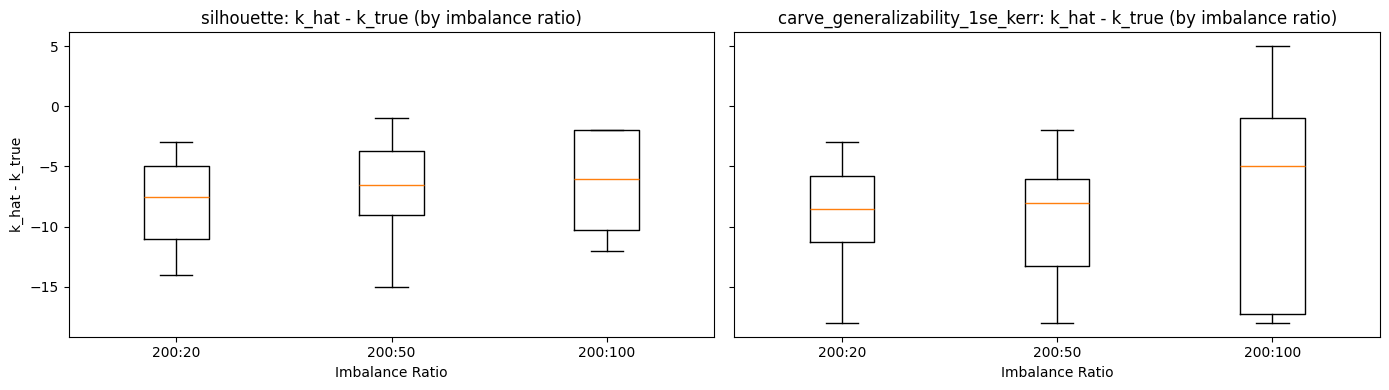

In [189]:
carve_col = "carve_generalizability_1se_kerr"

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

groups = []
labels = []
for ratio in sorted(res["ratio"].unique(), key=lambda s: int(s.split(":")[1])):
    vals = res.loc[res["ratio"] == ratio, "silhouette_kerr"].dropna().values
    groups.append(vals)
    labels.append(ratio)
axes[0].boxplot(groups, tick_labels=labels)
axes[0].set_title("silhouette: k_hat - k_true (by imbalance ratio)")
axes[0].set_xlabel("Imbalance Ratio")
axes[0].set_ylabel("k_hat - k_true")

if carve_col:
    groups = []
    for ratio in sorted(res["ratio"].unique(), key=lambda s: int(s.split(":")[1])):
        vals = res.loc[res["ratio"] == ratio, carve_col].dropna().values
        groups.append(vals)
    axes[1].boxplot(groups, tick_labels=labels)
    axes[1].set_title(f"{carve_col}: k_hat - k_true (by imbalance ratio)")
    axes[1].set_xlabel("Imbalance Ratio")

plt.tight_layout()
plt.show()

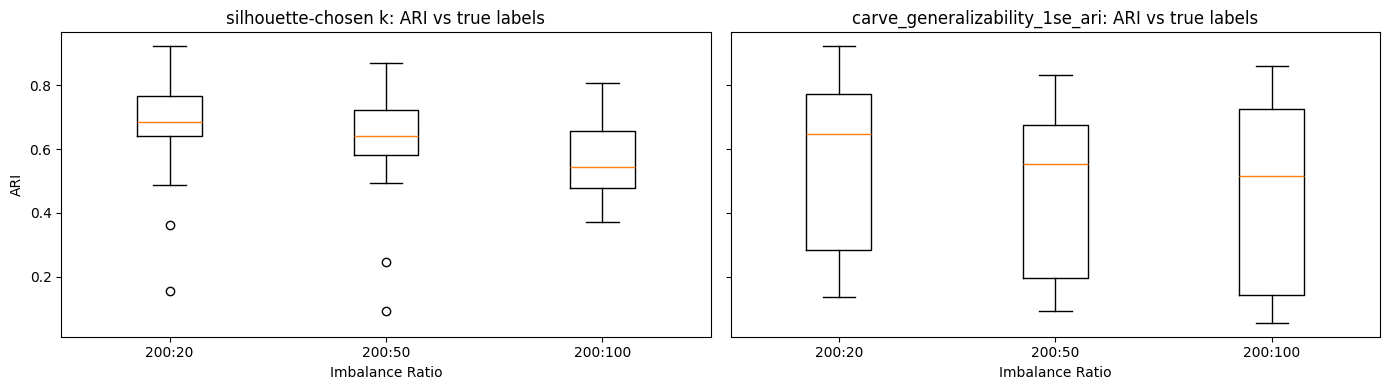

In [190]:
carve_col = "carve_generalizability_1se_ari"

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

groups = []
labels = []
for ratio in sorted(res["ratio"].unique(), key=lambda s: int(s.split(":")[1])):
    vals = res.loc[res["ratio"] == ratio, "silhouette_ari"].dropna().values
    groups.append(vals)
    labels.append(ratio)
axes[0].boxplot(groups, tick_labels=labels)
axes[0].set_title("silhouette-chosen k: ARI vs true labels")
axes[0].set_xlabel("Imbalance Ratio")
axes[0].set_ylabel("ARI")

if carve_col:
    groups = []
    for ratio in sorted(res["ratio"].unique(), key=lambda s: int(s.split(":")[1])):
        vals = res.loc[res["ratio"] == ratio, carve_col].dropna().values
        groups.append(vals)
    axes[1].boxplot(groups, tick_labels=labels)
    axes[1].set_title(f"{carve_col}: ARI vs true labels")
    axes[1].set_xlabel("Imbalance Ratio")

plt.tight_layout()
plt.show()

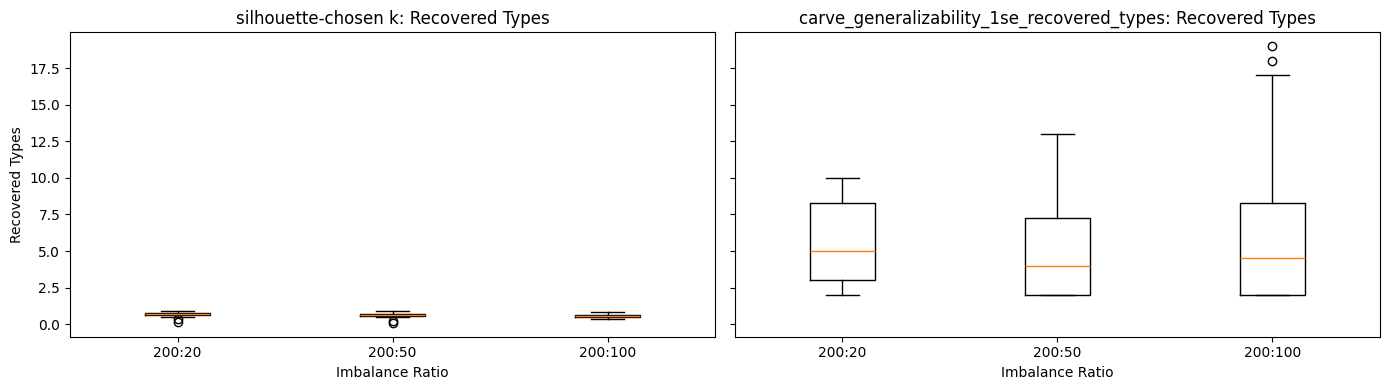

In [191]:
carve_col = "carve_generalizability_1se_recovered_types"

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

groups = []
labels = []
for ratio in sorted(res["ratio"].unique(), key=lambda s: int(s.split(":")[1])):
    vals = res.loc[res["ratio"] == ratio, "silhouette_ari"].dropna().values
    groups.append(vals)
    labels.append(ratio)
axes[0].boxplot(groups, tick_labels=labels)
axes[0].set_title("silhouette-chosen k: Recovered Types")
axes[0].set_xlabel("Imbalance Ratio")
axes[0].set_ylabel("Recovered Types")

if carve_col:
    groups = []
    for ratio in sorted(res["ratio"].unique(), key=lambda s: int(s.split(":")[1])):
        vals = res.loc[res["ratio"] == ratio, carve_col].dropna().values
        groups.append(vals)
    axes[1].boxplot(groups, tick_labels=labels)
    axes[1].set_title(f"{carve_col}: Recovered Types")
    axes[1].set_xlabel("Imbalance Ratio")

plt.tight_layout()
plt.show()

---

In [247]:
subset = res[(res["k_true"] == 10) & (res["minor_n"] == 20)].copy()
med = subset["silhouette_kerr"].median()
pick_id = int(subset.iloc[(subset["silhouette_kerr"] - med).abs().argsort()[:1]]["dataset_id"].values[0])

pick_id, med

(20, np.float64(-5.0))

seed: 202044

In [248]:
# reconstruct the seed used above
row = res.loc[res["dataset_id"] == pick_id].iloc[0]
seed = RANDOM_SEED + 10000*int(row.k_true) + 100*int(row.minor_n) + int(row.rep)

ad_sub, y_true_str, info = sample_yu_imbalance(
    adata, label_col, k_true=int(row.k_true),
    major_n=MAJOR_N, minor_n=int(row.minor_n), seed=seed
)

X_log = log_normalize_counts(ad_sub.X, target_sum=1e4)
gene_idx = top_var_genes(X_log, n_genes=2000)
X_eval = X_log[:, gene_idx]

y_true_codes, type_names = encode_labels(y_true_str)

In [249]:
np.unique(y_true_str)

array(['B cell', 'astrocyte of the cerebral cortex', 'hepatocyte',
       'keratinocyte stem cell', 'large intestine goblet cell',
       'leukocyte', 'luminal epithelial cell of mammary gland',
       'natural killer cell', 'oligodendrocyte',
       'skeletal muscle satellite cell'], dtype=object)

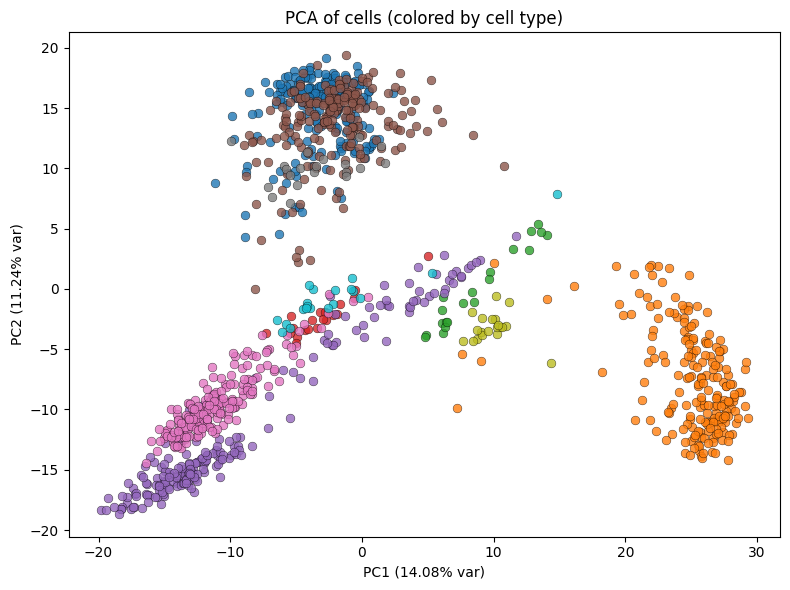

In [251]:
# Perform PCA on X_eval and plot explained variance
pca = PCA(n_components=2, random_state=seed)
pcs = pca.fit_transform(X_eval)

explained_var = pca.explained_variance_ratio_
explained_var_pct = explained_var * 100

plt.figure(figsize=(8, 6))
labels = pd.Categorical(y_true_str).categories
cmap = plt.get_cmap('tab10')
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}
for lab in labels:
    sel = pcs[pd.Categorical(y_true_str) == lab]
    plt.scatter(sel[:, 0], sel[:, 1], label=lab, color=color_map[lab], s=40, alpha=0.8, edgecolor='k', linewidth=0.3)

plt.xlabel(f"PC1 ({explained_var_pct[0]:.2f}% var)")
plt.ylabel(f"PC2 ({explained_var_pct[1]:.2f}% var)")
plt.title("PCA of cells (colored by cell type)")
plt.tight_layout()
plt.show()

In [252]:
best, curve = pick_k_baselines(X_eval, K_GRID, seed=seed, gap_refs=10)
val, carve_ks = run_carve(
    X_eval, K_GRID, seed=seed, B=100, rho=0.6, n_jobs=N_JOBS,
    ref_labels=y_true_codes, verbose=1
)

print("baseline k hats:", best)
print("carve k hats:", carve_ks)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 1100
[CARVE] n_features         : 2000
[CARVE] K                  : [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[CARVE] B (resamples)      : 100
[CARVE] rho (subsampling)  : 0.6
[CARVE] n_jobs             : 10
[CARVE] total configs      : 21
[CARVE] random_preprocess  : False
[CARVE] random_state       : 102042
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/21] est=SpectralClustering n_clusters=5 | ARI_stab=0.979±0.002  ARI_gen=0.927±0.003  ARI_avg=0.953±0.002
[CARVE] [2/21] est=SpectralClustering n_clusters=6 | ARI_stab=0.984±0.001  ARI_gen=0.938±0.002  ARI_avg=0.961±0.001
[CARVE] [3/21] est=SpectralClustering n_clusters=7 | ARI_stab=0.877±0.007  ARI_gen=0.822±0.005  ARI_avg=0.850±0.005
[CARVE] [4/21] est=SpectralClustering n_clusters=8 | ARI_stab=0.844±0.007  ARI_gen=0.787

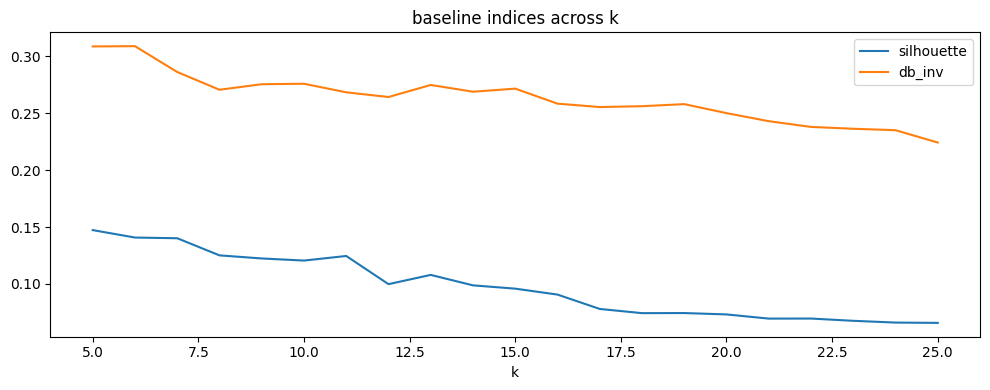

In [253]:
curve.plot(x="k", y=["silhouette", "db_inv"], figsize=(10,4))
plt.title("baseline indices across k")
plt.tight_layout()
plt.show()

In [254]:
# typical:
val.plot_results(measure="generalizability", rule="1se", interactive=True)

In [257]:
val.plot_clustering(measure="generalizability", rule="1se", interactive=True)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAIkAAAAAAAAAAAAAAAAAAAP' ... 'g2/RTz7z9bCO7zlPLvPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '149, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.9938787811896486,
                         'size': {'bdata': ('/O5jaTPVKkD87mNpM9UqQPzuY2kz1S' ... 'kz1SpA/O5jaTPVKkD87mNpM9UqQA=='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '17f777c8-292e-4653-b0bd-2fe7955104fc',
              'x': {'bdata': ('x59MwcpuV8FFqj/Bjr54wZvCWcH/+1' ... '3BivdpwRCIIcHaBYvBKERQwXoAKsE='),
  

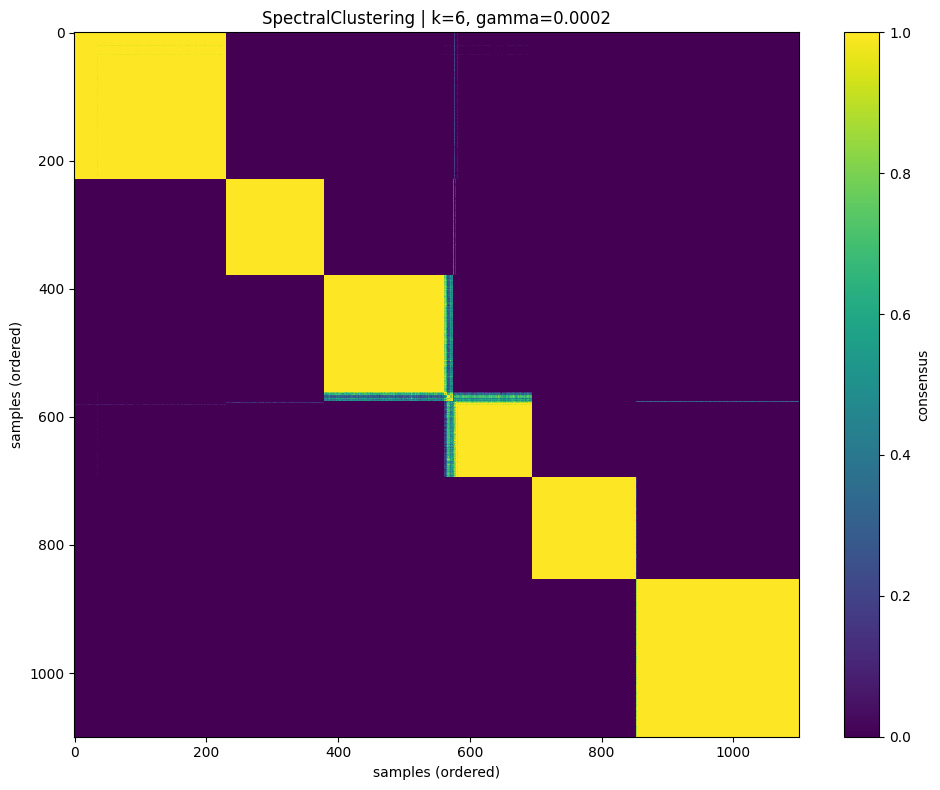

In [256]:
val.plot_consensus_matrix(measure="stability", rule="1se")

---